In [27]:
#loading filtered rna and atac data
import anndata
from anndata import AnnData
import pandas as pd

pb_atac_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/ATAC/celltypes_times/agg_atac_ct_time.h5ad")
pb_rna_ct_time = anndata.read_h5ad("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Pseudobulks/RNA/celltypes_times/agg_rna_ct_time.h5ad") 
gene_peaks_10kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_10kb.csv")
gene_peaks_20kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_20kb.csv")
gene_peaks_50kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_50kb.csv")
gene_peaks_100kb = pd.read_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_assignments_100kb.csv")


In [28]:
#check dimensions of the data
print(pb_atac_ct_time.X.shape)
print(pb_rna_ct_time.X.shape)

print(pb_atac_ct_time.obs_names)
print(pb_rna_ct_time.obs_names)

(196, 640834)
(196, 32057)
Index(['NMPs__0somites', 'NMPs__5somites', 'NMPs__10somites',
       'NMPs__15somites', 'PSM__0somites', 'PSM__5somites', 'PSM__10somites',
       'PSM__15somites', 'PSM__20somites', 'differentiating_neurons__5somites',
       ...
       'spinal_cord__5somites', 'spinal_cord__10somites',
       'spinal_cord__15somites', 'spinal_cord__20somites',
       'spinal_cord__30somites', 'tail_bud__0somites', 'tail_bud__5somites',
       'tail_bud__10somites', 'tail_bud__15somites', 'tail_bud__20somites'],
      dtype='object', length=196)
Index(['epidermis__15somites', 'pronephros__15somites', 'hindbrain__15somites',
       'spinal_cord__15somites', 'neural_optic2__15somites',
       'neural_floor_plate__15somites', 'neural_crest2__15somites',
       'PSM__15somites', 'optic_cup__15somites',
       'lateral_plate_mesoderm__15somites',
       ...
       'neural_crest2__10somites', 'muscle__10somites',
       'epidermis2__10somites', 'floor_plate__10somites',
       'he

In [29]:
#Reindex the dataframes to ensure they are in the same order
pb_atac_ct_time = pb_atac_ct_time[pb_rna_ct_time.obs_names, :]
pb_rna_ct_time = pb_rna_ct_time[pb_atac_ct_time.obs_names, :]
print(pb_atac_ct_time.obs_names.equals(pb_rna_ct_time.obs_names))  # Should return True

pb_rna_ct_time.shape

True


(196, 32057)

In [30]:
print(pb_atac_ct_time.X)
print(pb_rna_ct_time.X)

[[4.22694502e-07 6.76311203e-07 1.94439471e-06 ... 5.91772302e-07
  2.24822752e-03 1.84066548e-03]
 [0.00000000e+00 7.52470643e-07 9.40588304e-07 ... 9.40588304e-07
  2.35843111e-03 1.90958238e-03]
 [1.83118590e-07 1.37338943e-06 9.15592951e-07 ... 1.64806731e-06
  2.20300820e-03 1.78027893e-03]
 ...
 [4.10770344e-07 1.78000482e-06 5.06616757e-06 ... 1.09538758e-06
  2.15722892e-03 1.92391137e-03]
 [4.57123736e-07 6.85685604e-07 1.59993308e-06 ... 4.57123736e-07
  2.21110751e-03 2.02185829e-03]
 [2.63333289e-07 1.84333302e-06 3.68666604e-06 ... 2.10666631e-06
  1.79487969e-03 1.63345639e-03]]
[[1.70213019e-06 6.38298823e-07 1.48936392e-06 ... 3.72681406e-03
  4.25532549e-07 0.00000000e+00]
 [1.87578197e-06 4.68945492e-07 9.37890983e-07 ... 3.90068860e-03
  1.40683647e-06 4.68945492e-07]
 [8.51931471e-07 1.13590863e-06 3.12374873e-06 ... 4.00947348e-03
  8.51931471e-07 1.41988578e-06]
 ...
 [0.00000000e+00 0.00000000e+00 7.77981868e-07 ... 4.67333708e-03
  0.00000000e+00 0.00000000e+00]

In [37]:
#taking the minimum non-zero value in the pb_rna_ct_time matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np

non_zero_mask = (pb_rna_ct_time.X > 0)
epsilon_rna = np.min(pb_rna_ct_time.X[non_zero_mask])


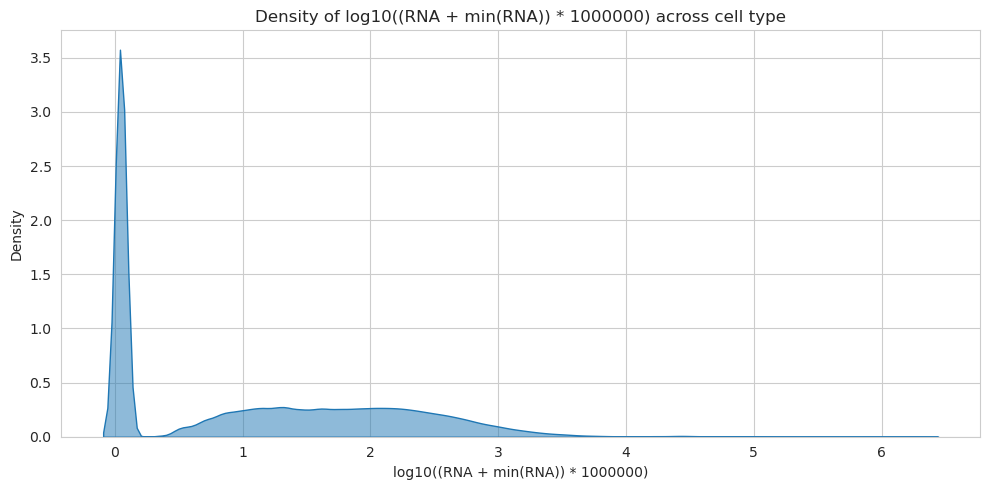

In [40]:
#Plotting the distribution of the value of the genes across all cell types in a boxplot for RNA data
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

P_rna_scaled = np.log10((pb_rna_ct_time.X+ epsilon_rna)*10000000) 

# RNA counts x samples
P_rna_scaled = P_rna_scaled.T.astype(float)

# convert to long format for seaborn
P_rna_scaled_plot = pd.DataFrame(P_rna_scaled, columns=pb_rna_ct_time.obs_names).melt(
	var_name="celltype",
	value_name="log_cpm"
)
#Plotting the distribution of values of the genes across all cell types in a density plot for RNA data
plt.figure(figsize=(10, 5))
sns.kdeplot(data=P_rna_scaled_plot, x="log_cpm", common_norm=False, fill=True, alpha=0.5)
plt.xlabel("log10((RNA + min(RNA)) * 1000000)")
plt.title("Density of log10((RNA + min(RNA)) * 1000000) across cell type")
plt.tight_layout()
plt.show()

In [34]:
#taking the minimum non-zero value in the pb_atac_ct_time matrix to add it to all values before log transformation to avoid taking log of zero
import numpy as np

non_zero_mask = (pb_atac_ct_time.X > 0)
epsilon_atac = np.min(pb_atac_ct_time.X[non_zero_mask])

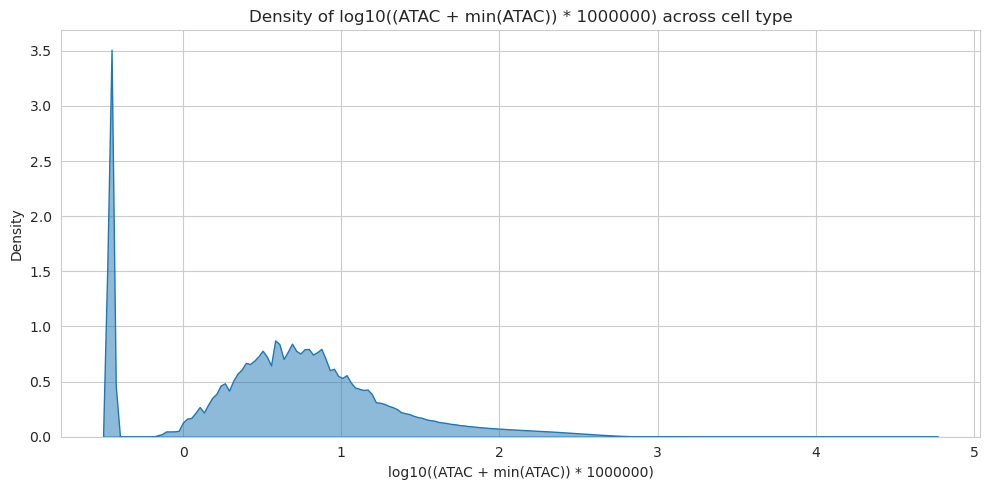

In [35]:
#Plotting the distribution of the value of the genes across all cell types in a boxplot for RNA data
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

P_atac_scaled = np.log10((pb_atac_ct_time.X+ epsilon_atac)*10000000) 

# ATAC counts x samples
P_atac_scaled = P_atac_scaled.T.astype(float)

# convert to long format for seaborn
P_atac_scaled_plot = pd.DataFrame(P_atac_scaled, columns=pb_atac_ct_time.obs_names).melt(
	var_name="celltype",
	value_name="log_cpm"
)
#Plotting the distribution of values of the genes across all cell types in a density plot for ATAC data
plt.figure(figsize=(10, 5))
sns.kdeplot(data=P_atac_scaled_plot, x="log_cpm", common_norm=False, fill=True, alpha=0.5)
plt.xlabel("log10((ATAC + min(ATAC)) * 1000000)")
plt.title("Density of log10((ATAC + min(ATAC)) * 1000000) across cell type")
plt.tight_layout()
plt.show()

# peak-wise correlation per gene
- For each gene, it loops through all assigned peaks. Computes one correlation per peak against the gene expression vector. Stores results as a nested dictionary:
- gene_peak_10kb_cor_results[gene_id][peak_id] = correlation
- This keeps full peak-level signal instead of collapsing peaks into one averaged accessibility profile.

In [9]:
# dictionary to save peak-wise correlation results per gene in 10kb window 
import ast
import numpy as np
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

#scaling the pesudobulked counts by adding the minimum non-zero value to avoid log(0) issues, multiplying by 10000000 to get counts per million, then taking np.log()
pb_rna_ct_time.X = np.log10((pb_rna_ct_time.X+ epsilon_rna)*10000000)
pb_atac_ct_time.X = np.log10((pb_atac_ct_time.X+ epsilon_atac)*10000000)
 
# 1. Compute correlations 
gene_peak_10kb_cor_results = {}

for gene_id in gene_peaks_10kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_10kb.loc[
        gene_peaks_10kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = assigned_peaks_raw

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

    peak_corrs = {}
    if len(assigned_peaks) == 0:
        gene_peak_10kb_cor_results[gene_id] = peak_corrs
        continue

    gene_expression = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel()

    for peak_id in assigned_peaks:
        peak_accessibility = np.asarray(pb_atac_ct_time[:, peak_id].X).ravel()

        if np.std(gene_expression) == 0 or np.std(peak_accessibility) == 0:
            peak_corrs[peak_id] = {"corr": np.nan, "pval": np.nan, "padj": np.nan}
        else:
            corr, pval = pearsonr(gene_expression, peak_accessibility)
            peak_corrs[peak_id] = {"corr": corr, "pval": pval, "padj": np.nan}  # padj filled below

    gene_peak_10kb_cor_results[gene_id] = peak_corrs


#2. Collect all valid p-values across every peak–gene pair 
pair_index = []   # keeps track of (gene_id, peak_id) so we can write padj back
pvals_all  = []

for gene_id, peak_corrs in gene_peak_10kb_cor_results.items():
    for peak_id, stats in peak_corrs.items():
        if not np.isnan(stats["pval"]):          # skip NaN (constant vectors)
            pair_index.append((gene_id, peak_id))
            pvals_all.append(stats["pval"])


# 3. Apply Benjamini-Hochberg FDR correction 
if len(pvals_all) > 0:
    _, padj_all, _, _ = multipletests(pvals_all, method="fdr_bh")

    # write adjusted p-values back into the results dictionary
    for (gene_id, peak_id), padj in zip(pair_index, padj_all):
        gene_peak_10kb_cor_results[gene_id][peak_id]["padj"] = padj

/tmp/ipykernel_861424/261642462.py:8: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  pb_rna_ct_time.X = np.log10((pb_rna_ct_time.X+ epsilon_rna)*10000000)
/tmp/ipykernel_861424/261642462.py:9: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
  pb_atac_ct_time.X = np.log10((pb_atac_ct_time.X+ epsilon_atac)*10000000)


In [10]:
# dictionary to save peak-wise correlation results per gene in 20kb window
import ast
import numpy as np
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# 1. Compute correlations 
gene_peak_20kb_cor_results = {}

for gene_id in gene_peaks_20kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_20kb.loc[
        gene_peaks_20kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = assigned_peaks_raw

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

    peak_corrs = {}
    if len(assigned_peaks) == 0:
        gene_peak_20kb_cor_results[gene_id] = peak_corrs
        continue

    gene_expression = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel()

    for peak_id in assigned_peaks:
        peak_accessibility = np.asarray(pb_atac_ct_time[:, peak_id].X).ravel()

        if np.std(gene_expression) == 0 or np.std(peak_accessibility) == 0:
            peak_corrs[peak_id] = {"corr": np.nan, "pval": np.nan, "padj": np.nan}
        else:
            corr, pval = pearsonr(gene_expression, peak_accessibility)
            peak_corrs[peak_id] = {"corr": corr, "pval": pval, "padj": np.nan}  # padj filled below

    gene_peak_20kb_cor_results[gene_id] = peak_corrs


#2. Collect all valid p-values across every peak–gene pair 
pair_index = []   # keeps track of (gene_id, peak_id) so we can write padj back
pvals_all  = []

for gene_id, peak_corrs in gene_peak_20kb_cor_results.items():
    for peak_id, stats in peak_corrs.items():
        if not np.isnan(stats["pval"]):          # skip NaN (constant vectors)
            pair_index.append((gene_id, peak_id))
            pvals_all.append(stats["pval"])


# 3. Apply Benjamini-Hochberg FDR correction 
if len(pvals_all) > 0:
    _, padj_all, _, _ = multipletests(pvals_all, method="fdr_bh")

    # write adjusted p-values back into the results dictionary
    for (gene_id, peak_id), padj in zip(pair_index, padj_all):
        gene_peak_20kb_cor_results[gene_id][peak_id]["padj"] = padj

In [11]:
# dictionary to save peak-wise correlation results per gene in 50kb window
import ast
import numpy as np
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# 1. Compute correlations 
gene_peak_50kb_cor_results = {}

for gene_id in gene_peaks_50kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_50kb.loc[
        gene_peaks_50kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = assigned_peaks_raw

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

    peak_corrs = {}
    if len(assigned_peaks) == 0:
        gene_peak_50kb_cor_results[gene_id] = peak_corrs
        continue

    gene_expression = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel()

    for peak_id in assigned_peaks:
        peak_accessibility = np.asarray(pb_atac_ct_time[:, peak_id].X).ravel()

        if np.std(gene_expression) == 0 or np.std(peak_accessibility) == 0:
            peak_corrs[peak_id] = {"corr": np.nan, "pval": np.nan, "padj": np.nan}
        else:
            corr, pval = pearsonr(gene_expression, peak_accessibility)
            peak_corrs[peak_id] = {"corr": corr, "pval": pval, "padj": np.nan}  # padj filled below

    gene_peak_50kb_cor_results[gene_id] = peak_corrs


#2. Collect all valid p-values across every peak–gene pair 
pair_index = []   # keeps track of (gene_id, peak_id) so we can write padj back
pvals_all  = []

for gene_id, peak_corrs in gene_peak_50kb_cor_results.items():
    for peak_id, stats in peak_corrs.items():
        if not np.isnan(stats["pval"]):          # skip NaN (constant vectors)
            pair_index.append((gene_id, peak_id))
            pvals_all.append(stats["pval"])


# 3. Apply Benjamini-Hochberg FDR correction 
if len(pvals_all) > 0:
    _, padj_all, _, _ = multipletests(pvals_all, method="fdr_bh")

    # write adjusted p-values back into the results dictionary
    for (gene_id, peak_id), padj in zip(pair_index, padj_all):
        gene_peak_50kb_cor_results[gene_id][peak_id]["padj"] = padj

In [12]:
# dictionary to save peak-wise correlation results per gene in 100kb window
import ast
import numpy as np
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests

# 1. Compute correlations 
gene_peak_100kb_cor_results = {}

for gene_id in gene_peaks_100kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_100kb.loc[
        gene_peaks_100kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]

    if isinstance(assigned_peaks_raw, str):
        assigned_peaks = ast.literal_eval(assigned_peaks_raw)
    else:
        assigned_peaks = assigned_peaks_raw

    assigned_peaks = [p for p in assigned_peaks if p in pb_atac_ct_time.var_names]

    peak_corrs = {}
    if len(assigned_peaks) == 0:
        gene_peak_100kb_cor_results[gene_id] = peak_corrs
        continue

    gene_expression = np.asarray(pb_rna_ct_time[:, gene_id].X).ravel()

    for peak_id in assigned_peaks:
        peak_accessibility = np.asarray(pb_atac_ct_time[:, peak_id].X).ravel()

        if np.std(gene_expression) == 0 or np.std(peak_accessibility) == 0:
            peak_corrs[peak_id] = {"corr": np.nan, "pval": np.nan, "padj": np.nan}
        else:
            corr, pval = pearsonr(gene_expression, peak_accessibility)
            peak_corrs[peak_id] = {"corr": corr, "pval": pval, "padj": np.nan}  # padj filled below

    gene_peak_100kb_cor_results[gene_id] = peak_corrs


#2. Collect all valid p-values across every peak–gene pair 
pair_index = []   # keeps track of (gene_id, peak_id) so we can write padj back
pvals_all  = []

for gene_id, peak_corrs in gene_peak_100kb_cor_results.items():
    for peak_id, stats in peak_corrs.items():
        if not np.isnan(stats["pval"]):          # skip NaN (constant vectors)
            pair_index.append((gene_id, peak_id))
            pvals_all.append(stats["pval"])


# 3. Apply Benjamini-Hochberg FDR correction 
if len(pvals_all) > 0:
    _, padj_all, _, _ = multipletests(pvals_all, method="fdr_bh")

    # write adjusted p-values back into the results dictionary
    for (gene_id, peak_id), padj in zip(pair_index, padj_all):
        gene_peak_100kb_cor_results[gene_id][peak_id]["padj"] = padj

In [13]:
for gene_id in gene_peaks_20kb["gene_id"]:
    assigned_peaks_raw = gene_peaks_20kb.loc[
        gene_peaks_20kb["gene_id"] == gene_id, "assigned_peaks"
    ].iloc[0]
x = pb_rna_ct_time[:, gene_id].X
print(x.shape)

(196, 1)


In [14]:
# Build one tidy table across all windows and save as CSV for downstream analysis
import numpy as np
import pandas as pd

window_assignments = {
    "10kb":  gene_peak_10kb_cor_results,
    "20kb":  gene_peak_20kb_cor_results,
    "50kb":  gene_peak_50kb_cor_results,
    "100kb": gene_peak_100kb_cor_results,
}

all_window_results = []

for window_label, cor_results in window_assignments.items():
    for gene, peaks in cor_results.items():
        for peak, stats in peaks.items():

            # guard: skip NaN entries (constant vectors)
            if not isinstance(stats, dict):
                continue

            corr = stats.get("corr", np.nan)
            pval = stats.get("pval", np.nan)
            padj = stats.get("padj", np.nan)

            # keep only rows with finite, valid values
            if np.isfinite(corr) and np.isfinite(pval) and 0 < pval <= 1:
                all_window_results.append(
                    {
                        "window":           window_label,
                        "gene":             gene,
                        "peak":             peak,
                        "correlation":      corr,
                        "pvalue":           pval,
                        "neglog10_pvalue":  -np.log10(pval),
                        "padj":             padj,
                        "neglog10_padj":    -np.log10(padj) if np.isfinite(padj) and padj > 0 else np.nan,
                    }
                )

cor_res_df = pd.DataFrame(all_window_results)

# make window an ordered categorical for correct plot ordering
cor_res_df["window"] = pd.Categorical(
    cor_res_df["window"],
    categories=["10kb", "20kb", "50kb", "100kb"],
    ordered=True
)

#save the correlation results as a csv file
cor_res_df.to_csv("/home/fgsasse_lrs_1/Downloads/BA/BA_data/Rmd_n_notebook/gene_peak_correlation_ct_time_results.csv", index=False)
print(cor_res_df.shape)
print(cor_res_df.head())

(3308528, 8)
  window   gene           peak  correlation        pvalue  neglog10_pvalue  \
0   10kb  rpl24    1-2372-3057    -0.311027  9.118685e-06         5.040068   
1   10kb  rpl24    1-3427-4032    -0.405068  3.884092e-09         8.410711   
2   10kb  rpl24    1-4469-7268    -0.167507  1.894020e-02         1.722615   
3   10kb  rpl24    1-9541-9969    -0.148999  3.713353e-02         1.430234   
4   10kb  rpl24  1-11007-12962    -0.304377  1.441907e-05         4.841063   

           padj  neglog10_padj  
0  6.425554e-05       4.192089  
1  5.260168e-08       7.279000  
2  5.040299e-02       1.297544  
3  8.728105e-02       1.059080  
4  9.717434e-05       4.012448  


# Plotting the correlation results (ct_time)

CDF = Cumulative Distribution Function
- "What fraction of all peak–gene pairs in this window have padj ≤ t?

1) CDF curves

The curves shows the continuously across all thresholds:

- The 10kb curve rises the steepest near zero, meaning a large fraction of its pairs have very small padj values — its peaks are highly enriched for regulatory signal because they are all proximal to the TSS.
- Curves progressively flatten from 10kb → 100kb in the low-threshold region (left of the red dashed line), reflecting the dilution effect described above. The curves converge toward 1.0 at the right, which is expected — at padj = 1.0, all pairs are included by definition.
- The separation between curves is largest between 0 and ~0.3, exactly the biologically meaningful range. Beyond padj ~0.6 the curves bunch together, meaning the non-significant bulk of pairs behaves similarly regardless of window size.
Biological conclusion


The data shows proximity effect: regulatory peak–gene relationships are strongest and most enriched close to the TSS, with signal density falling off as the window is extend. The 10kb window is the most statistically clean. The additional ~188,000 significant pairs gained by going to 100kb represent candidate distal regulatory elements (enhancers) worth following up, but they come embedded in a much larger background of non-functional distal peaks and should be interpreted with higher scrutiny.

2) Proportion of significant peak-gene pairs
The bars show a clear monotonic decrease in the proportion of significant pairs as the window grows.The absolute number of significant pairs keeps growing (54k → 242k) even as the proportion shrinks. This tells us two things simultaneously:
- Larger windows do capture additional real regulatory peaks — it's not just adding noise, because the absolute count of significant pairs nearly quintuples from 10kb to 100kb
- But the majority of newly added distal peaks are non-regulatory — they dilute the signal, which is why BH correction becomes progressively stricter and the proportion falls

All four windows sit well above the 5% dashed baseline, which is the proportion we would expect under the null hypothesis of no signal. This confirms the correlation analysis is capturing genuine peak–gene associations and is not dominated by false discoveries.

Goal -> Best plot
- Overall shape comparison -> Overlapping KDE
- Median + spread in one view -> Violin + boxplot
- Rigorous, assumption-free comparison -> ECDF
- Simple biological summary -> Stacked bar

window      100kb    10kb    20kb    50kb
threshold                                
0.001      0.0852  0.1976  0.1564  0.1128
0.010      0.1374  0.2774  0.2293  0.1744
0.050      0.2124  0.3751  0.3228  0.2585
0.100      0.2682  0.4392  0.3859  0.3183
0.200      0.3543  0.5276  0.4757  0.4071


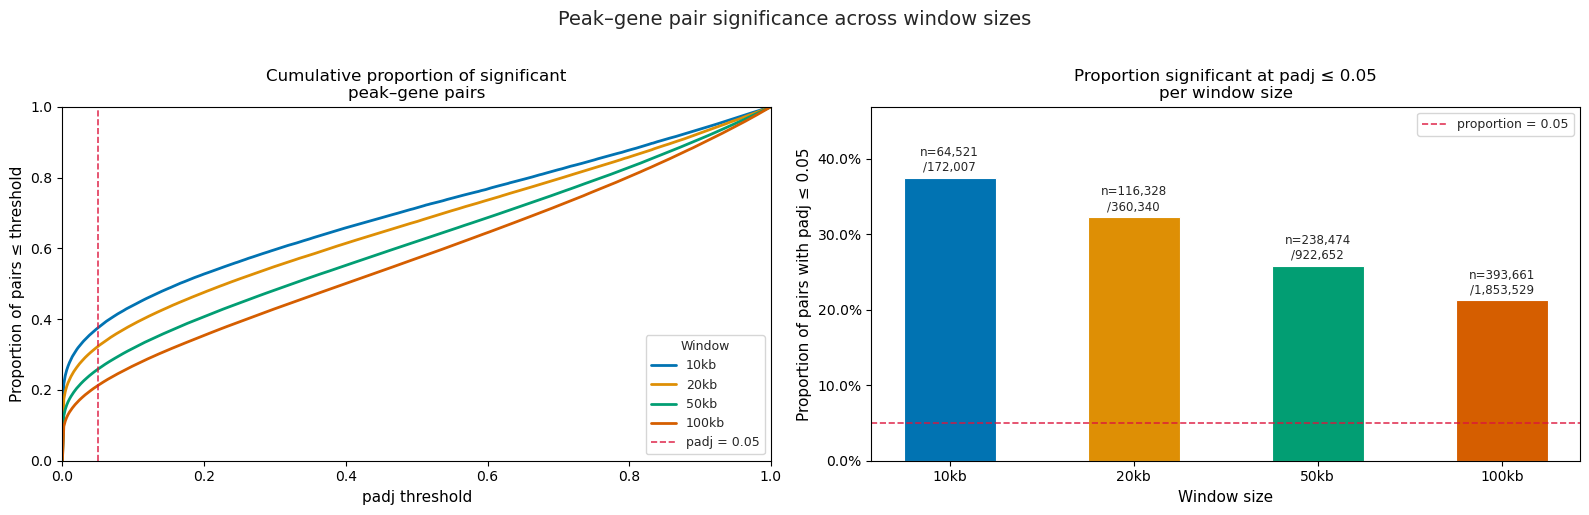

In [15]:
#Plotting the proportion of significant correlations (padj < 0.05) for each window size
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# 1. Continuous proportion curve across thresholds 
thresholds   = np.linspace(0, 1, 500)          # padj thresholds from 0 to 1
window_labels = ["10kb", "20kb", "50kb", "100kb"]

# build a tidy table: one row per (window, threshold)
prop_records = []
for window_label in window_labels:
    subset = cor_res_df[cor_res_df["window"] == window_label]["padj"].dropna()
    n_total = len(subset)
    if n_total == 0:
        continue
    for t in thresholds:
        prop = (subset <= t).sum() / n_total
        prop_records.append({
            "window":    window_label,
            "threshold": t,
            "proportion": prop,
            "n_total":   n_total,
        })

prop_df = pd.DataFrame(prop_records)

# 2. Summary table at biologically meaningful cutoffs 
cutoffs = [0.001, 0.01, 0.05, 0.1, 0.2]
summary_records = []
for window_label in window_labels:
    subset = cor_res_df[cor_res_df["window"] == window_label]["padj"].dropna()
    n_total = len(subset)
    for t in cutoffs:
        n_sig  = (subset <= t).sum()
        prop   = n_sig / n_total if n_total > 0 else np.nan
        summary_records.append({
            "window":     window_label,
            "threshold":  t,
            "n_total":    n_total,
            "n_sig":      n_sig,
            "proportion": prop,
        })

summary_df = pd.DataFrame(summary_records)
print(summary_df.pivot(index="threshold", columns="window", values="proportion")
                .round(4)
                .to_string())

# 3. Plot 
palette = sns.color_palette("colorblind", n_colors=len(window_labels))
color_map = dict(zip(window_labels, palette))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.set_style("whitegrid")

# --- left panel: full proportion curve ---------------------------------------
ax = axes[0]
for window_label in window_labels:
    wdf = prop_df[prop_df["window"] == window_label]
    ax.plot(
        wdf["threshold"], wdf["proportion"],
        label=window_label,
        color=color_map[window_label],
        linewidth=2.0
    )

ax.axvline(0.05, color="crimson", linestyle="--",
           linewidth=1.2, alpha=0.85, label="padj = 0.05")
ax.set_xlabel("padj threshold", fontsize=11)
ax.set_ylabel("Proportion of pairs ≤ threshold", fontsize=11)
ax.set_title("Cumulative proportion of significant\npeak–gene pairs", fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(title="Window", fontsize=9, title_fontsize=9)

# --- right panel: bar chart at fixed cutoffs ---------------------------------
ax = axes[1]
bar_df = summary_df[summary_df["threshold"] == 0.05].copy()
bars = ax.bar(
    bar_df["window"],
    bar_df["proportion"],
    color=[color_map[w] for w in bar_df["window"]],
    edgecolor="white",
    linewidth=0.8,
    width=0.5
)

# annotate bars with absolute counts
for bar, (_, row) in zip(bars, bar_df.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"n={int(row['n_sig']):,}\n/{int(row['n_total']):,}",
        ha="center", va="bottom", fontsize=8.5
    )

ax.axhline(0.05, color="crimson", linestyle="--",
           linewidth=1.2, alpha=0.85, label="proportion = 0.05")
ax.set_xlabel("Window size", fontsize=11)
ax.set_ylabel("Proportion of pairs with padj ≤ 0.05", fontsize=11)
ax.set_title("Proportion significant at padj ≤ 0.05\nper window size", fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.set_ylim(0, bar_df["proportion"].max() * 1.25)
ax.legend(fontsize=9)

fig.suptitle("Peak–gene pair significance across window sizes", y=1.02, fontsize=14)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_proportion_significant_ct_time.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [16]:
# ── classify every peak–gene pair into one of three categories ────────────────
def classify_pair(row):
    if row["padj"] <= 0.05 and row["correlation"] < 0:
        return "sig. negative"
    elif row["padj"] <= 0.05 and row["correlation"] > 0:
        return "sig. positive"
    else:
        return "non-significant"

cor_res_df["category"] = cor_res_df.apply(classify_pair, axis=1)

In [17]:
# counting the number of significant peaks and non-significant peaks for each gene in all window sizes in cor_res_df, but with a category column instead of separate columns for sig pos, sig neg, and non-sig
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

agg_cor_df = (
    cor_res_df
    .dropna(subset=["correlation", "padj"])
    .groupby(["window", "gene", "category"])
    .size()
    .reset_index(name="count")
)
agg_cor_df.head()

/tmp/ipykernel_861424/1700161589.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["window", "gene", "category"])


,window,gene,category,count
0,10kb,a1cf,non-significant,2
1,10kb,a1cf,sig. negative,0
2,10kb,a1cf,sig. positive,9
3,10kb,a2ml,non-significant,11
4,10kb,a2ml,sig. negative,0


# notice: the larger windows include the gene-peak pairs already occuring in the smaller window sizes!

/tmp/ipykernel_861424/2021222867.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_861424/2021222867.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(category_order, fontsize=9, rotation=15, ha="right")
/tmp/ipykernel_861424/2021222867.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_861424/2021222867.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(category_order, fontsize=9, rotation=15, ha="right")
/tmp/ipykernel_861424/2021222867.py:30: 

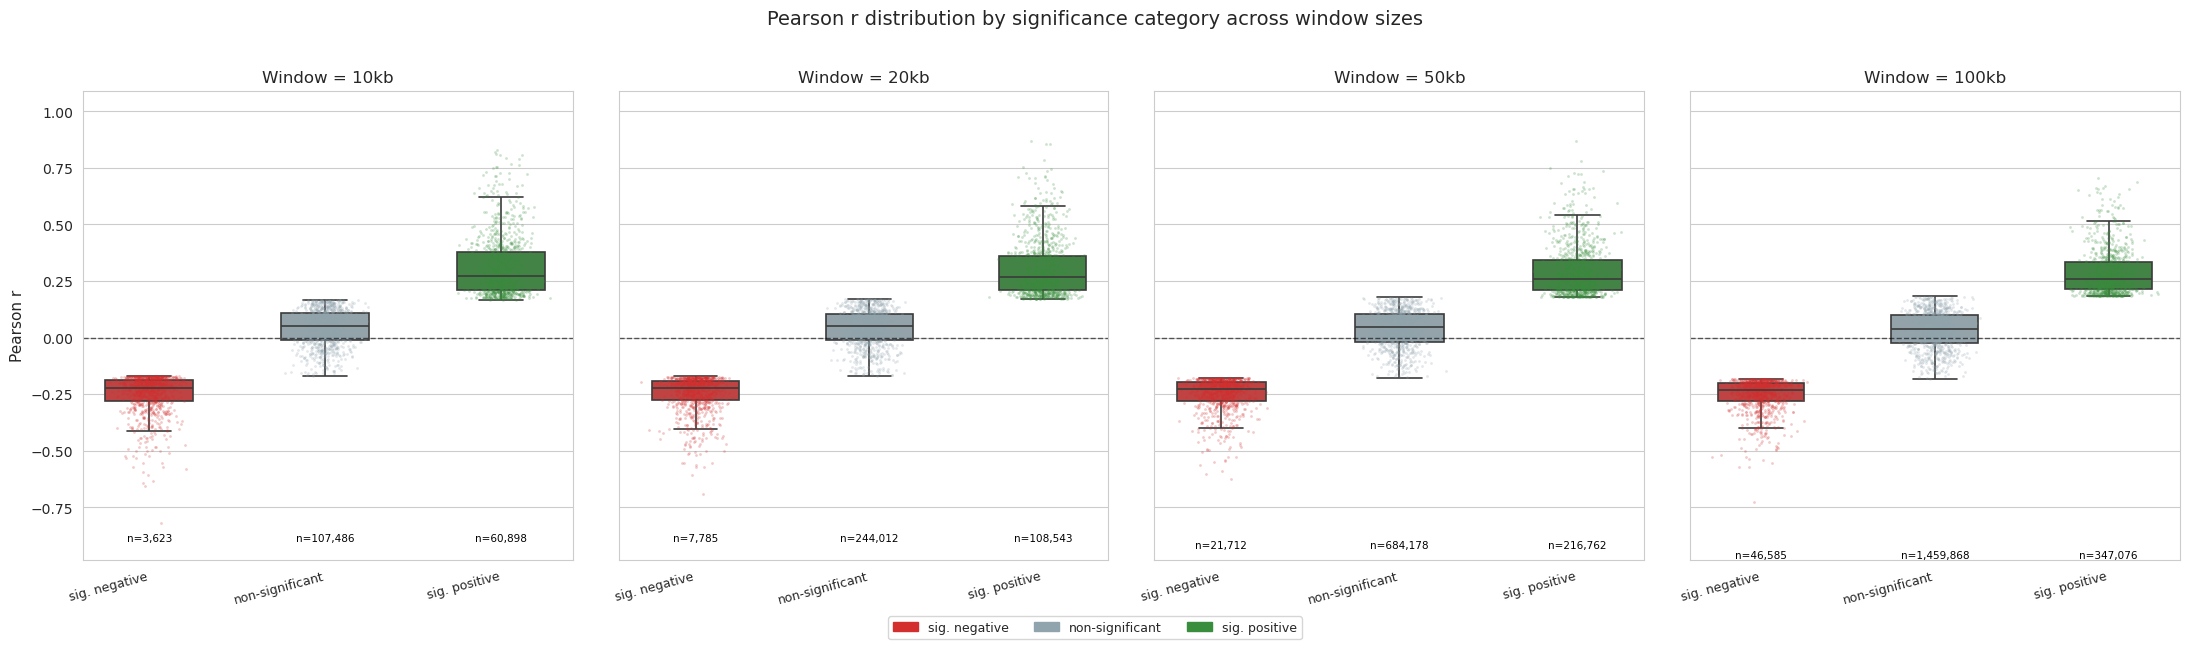

In [18]:
#Boxplot of correlation coefficients for significant pairs (padj ≤ 0.05) across window sizes
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# fixed order and colours for all panels
category_order  = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative":  "#D32F2F",   # red
    "non-significant": "#90A4AE",  # grey
    "sig. positive":  "#388E3C",   # green
}

# ── plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharey=True)

for i, (ax, window_label) in enumerate(zip(axes, window_labels)):
    subset = cor_res_df[
        cor_res_df["window"] == window_label
    ].dropna(subset=["correlation", "padj"])

    if subset.empty:
        ax.text(0.5, 0.5, "No data",
                transform=ax.transAxes, ha="center", va="center")
        ax.set_title(f"Window = {window_label}", fontsize=12)
        continue

    # ── boxplot ───────────────────────────────────────────────────────────────
    sns.boxplot(
        data=subset,
        x="category",
        y="correlation",
        order=category_order,
        palette=category_colors,
        width=0.5,
        linewidth=1.2,
        flierprops=dict(
            marker=".",
            markersize=1.5,
            alpha=0.2,
            markeredgewidth=0
        ),
        ax=ax
    )

    # ── overlay stripplot for individual points (downsampled to avoid overplot)
    for cat in category_order:
        cat_data = subset[subset["category"] == cat]
        # downsample to max 500 points per category for readability
        if len(cat_data) > 1000:
            cat_data = cat_data.sample(1000, random_state=42)
        x_pos = category_order.index(cat)
        ax.scatter(
            np.random.normal(x_pos, 0.08, size=len(cat_data)),
            cat_data["correlation"],
            color=category_colors[cat],
            alpha=0.25,
            s=4,
            linewidths=0,
            zorder=2
        )

    # ── annotate with n per category ─────────────────────────────────────────
    for j, cat in enumerate(category_order):
        n = (subset["category"] == cat).sum()
        ax.text(
            j, ax.get_ylim()[0],
            f"n={n:,}",
            ha="center", va="bottom",
            fontsize=7.5, color="black"
        )

    # ── reference line at r = 0 ───────────────────────────────────────────────
    ax.axhline(0.0, color="black", linestyle="--",
               linewidth=1.0, alpha=0.6)

    ax.set_title(f"Window = {window_label}", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Pearson r" if i == 0 else "", fontsize=11)
    ax.set_xticklabels(category_order, fontsize=9, rotation=15, ha="right")

# ── shared legend ─────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=3,
    fontsize=9,
    frameon=True,
    bbox_to_anchor=(0.5, -0.04)
)

fig.suptitle(
    "Pearson r distribution by significance category across window sizes",
    y=1.02, fontsize=14
)
plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_correlation_boxplot_categories_ct_time.png",
    dpi=300, bbox_inches="tight"
)
plt.show()

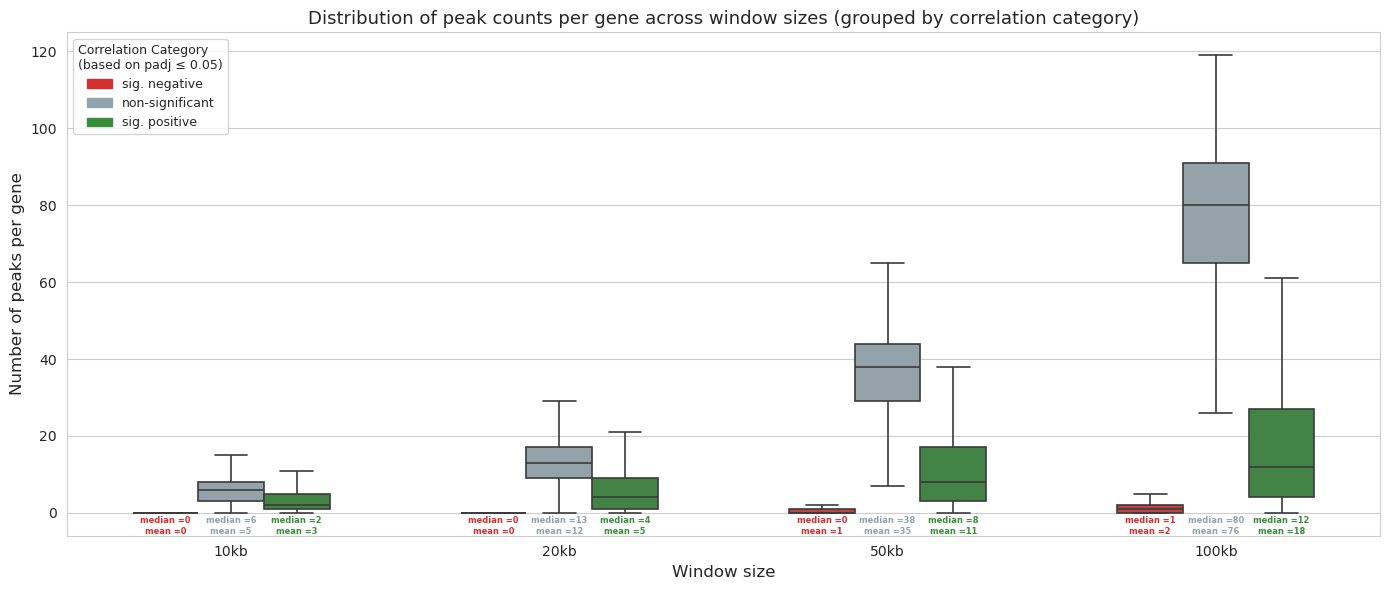

In [21]:
# Plotting the distribution of the number of peaks per gene across all window sizes
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

# ensure plot order is stable
window_labels = ["10kb", "20kb", "50kb", "100kb"]
category_order = ["sig. negative", "non-significant", "sig. positive"]
category_colors = {
    "sig. negative": "#D32F2F",
    "non-significant": "#90A4AE",
    "sig. positive": "#388E3C",
}

# agg_df is already in long format: (gene, window, category, count)
# ensure window is categorical for proper ordering
plot_df = agg_cor_df.copy()
plot_df["window"] = pd.Categorical(
    plot_df["window"],
    categories=window_labels,
    ordered=True,
)

# ── plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

sns.boxplot(
    data=plot_df.dropna(subset=["count"]),
    x="window",
    y="count",
    hue="category",
    hue_order=category_order,
    order=window_labels,
    palette=category_colors,
    width=0.6,
    linewidth=1.2,
    flierprops=dict(
        marker=".",
        markersize=1.5,
        alpha=0.2,
        markeredgewidth=0,
    ),
    ax=ax,
)

# annotate median count for each window-category box
n_groups = len(category_order)
total_width = 0.6
box_width = total_width / n_groups

for w_idx, window_label in enumerate(window_labels):
    w_subset = plot_df[plot_df["window"] == window_label]
    for c_idx, cat in enumerate(category_order):
        vals = w_subset[w_subset["category"] == cat]["count"]
        if vals.empty:
            continue

        x_pos = (
            w_idx
            - total_width / 2
            + box_width / 2
            + c_idx * box_width
        )
        y_med = vals.median()
        y_mean = vals.mean()
        ax.text(
            x=x_pos,
            y=ax.get_ylim()[0] + 0.00001  * (ax.get_ylim()[1] - ax.get_ylim()[0]), # place text slightly above x-axis
            s=f"median ={int(y_med):,}\nmean ={int(y_mean):,}",
            ha="center",
            va="bottom",
            fontsize=6,
            fontweight="bold",
            color=category_colors[cat],
        )

# ── labels + legend ───────────────────────────────────────────────────────────
ax.set_xlabel("Window size", fontsize=12)
ax.set_ylabel("Number of peaks per gene", fontsize=12)
ax.set_title("Distribution of peak counts per gene across window sizes (grouped by correlation category)", fontsize=13)

legend_patches = [
    mpatches.Patch(color=category_colors[cat], label=cat)
    for cat in category_order
]
ax.legend(
    handles=legend_patches,
    title="Correlation Category\n(based on padj ≤ 0.05)",
    fontsize=9,
    title_fontsize=9,
    frameon=True,
    loc="upper left",
)

plt.tight_layout()

fig.savefig(
    "/home/fgsasse_lrs_1/Downloads/BA/BA_data/Correlations/Graphics/"
    "peak_gene_count_boxplot_aggregated_ct_time.png",
    dpi=300, bbox_inches="tight"
)
plt.show()